In [1]:
# SET PYTHONPATH to the parent directory 
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import torch
from torchvision import transforms
import torchstain
from hippy2d.datasets import ColorectalHistology

# Plot some samples from the histology dataset
# load images from histology dataset
dataset = ColorectalHistology(data_dir="/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/data",
                              batch_size=64,
                              macenko_normalizer=False)
dataset.prepare_data()
dataset.setup(stage=None)

train_loader = dataset.train_dataloader()

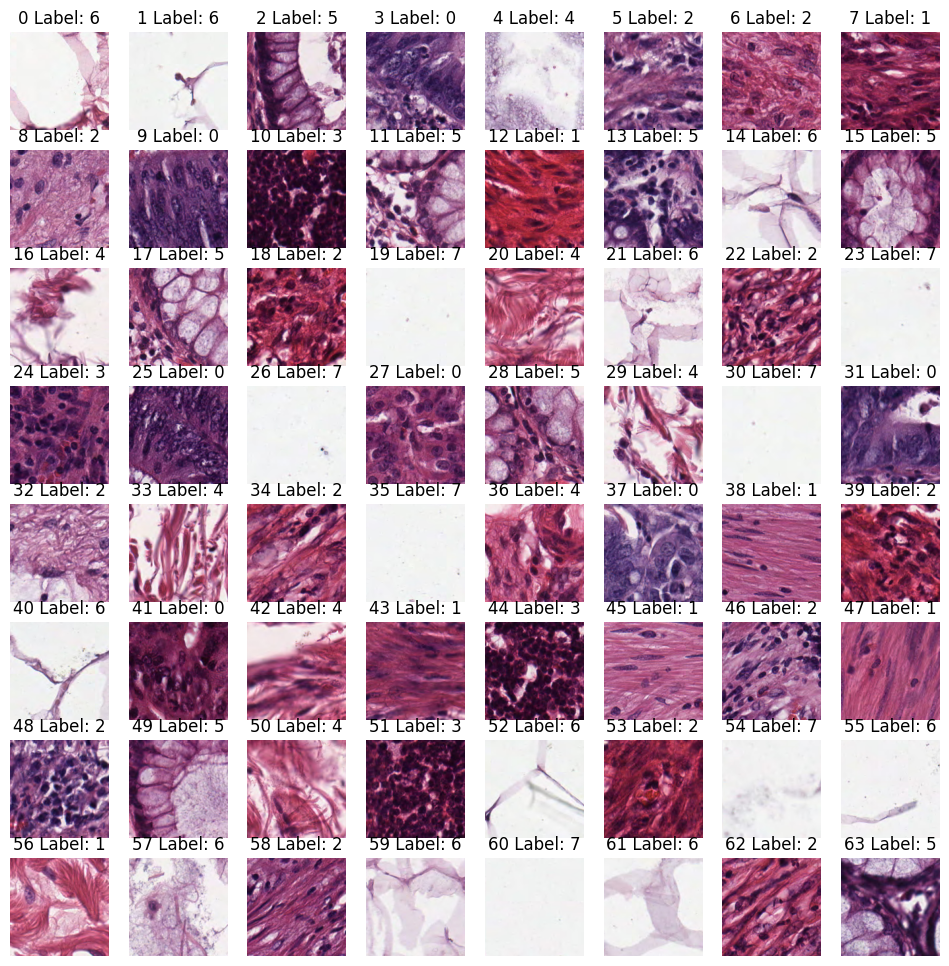

In [3]:
list_all_labels = []
list_all_imgs = []
# plot 8 examples
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
target_imgs, target_labels = [], []
target_ids = [ 
    # class 0 - tumor
    3, 9, 25,31,27,
    # class 1 - stroma
    7, 12, 38, 43,
    # class 2 - complex stroma
    22, 5, 34, 46,
    # class 3 - lymphocytes
    10, 51, 24, 44,
    # class 4 - debris
    36, 33, 50

]
others_imgs, others_labels = [], []
for i in range(64):
    ax = axes[i // 8, i % 8]
    item = train_loader.dataset[i]
    img, label = item['image'].to(torch.uint8), item['label']
    if i in target_ids:
        target_imgs.append(img)
        target_labels.append(label)
    else:
        others_imgs.append(img)
        others_labels.append(label)
    img = img.permute(1, 2, 0).numpy()  # CHW to HWC
    ax.imshow(img)
    ax.set_title(f"{i} Label: {label}")
    ax.axis('off')

In [4]:
train_loader.dataset[i]

{'image': Image([[[137, 150, 148,  ..., 166, 179, 174],
         [121, 143, 152,  ..., 153, 166, 151],
         [113, 130, 141,  ..., 136, 137, 123],
         ...,
         [127, 131, 138,  ..., 135, 149, 165],
         [117, 114, 126,  ..., 125, 142, 160],
         [121, 120, 129,  ..., 117, 138, 162]],
 
        [[ 94, 108, 106,  ..., 117, 130, 125],
         [ 82, 101, 110,  ..., 104, 117, 104],
         [ 76,  88,  99,  ...,  90,  91,  78],
         ...,
         [ 79,  88,  95,  ...,  86, 100, 111],
         [ 68,  69,  81,  ...,  75,  92, 105],
         [ 72,  72,  81,  ...,  70,  91, 106]],
 
        [[148, 154, 152,  ..., 157, 170, 165],
         [137, 147, 156,  ..., 144, 157, 146],
         [127, 134, 145,  ..., 129, 130, 119],
         ...,
         [137, 141, 148,  ..., 124, 138, 147],
         [131, 126, 138,  ..., 118, 135, 147],
         [135, 128, 137,  ..., 114, 135, 153]]], dtype=torch.uint8, ),
 'label': 5,
 'filename': "b'14A08_CRC-Prim-HE-05.tif_Row_1_Col_1351.tif'

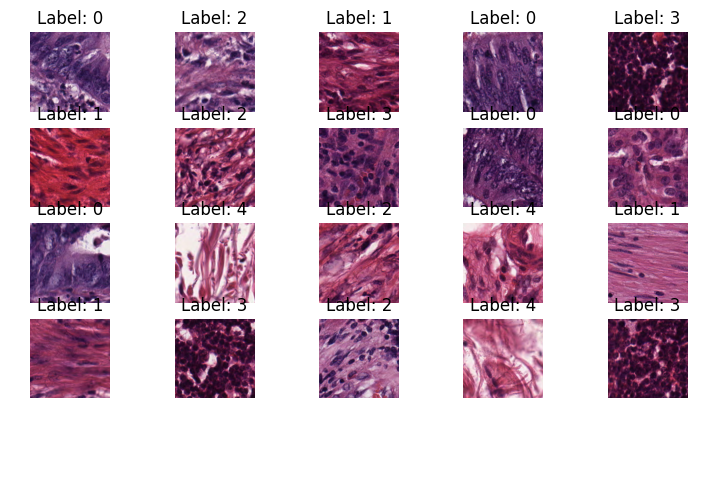

In [ ]:
# plot target images
fig, axes = plt.subplots(5, 5, figsize=(9, 6))
for i in range(25):
    ax = axes[i // 5, i % 5]
    if i >= len(target_imgs):
        ax.axis('off')
        continue
    img = target_imgs[i].permute(1, 2, 0).numpy()  # CHW to HWC
    label = target_labels[i]
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

In [6]:
normalizer = torchstain.normalizers.MultiMacenkoNormalizer(backend='torch')
normalizer.fit(target_imgs)

In [14]:
img.shape

(150, 3, 150)

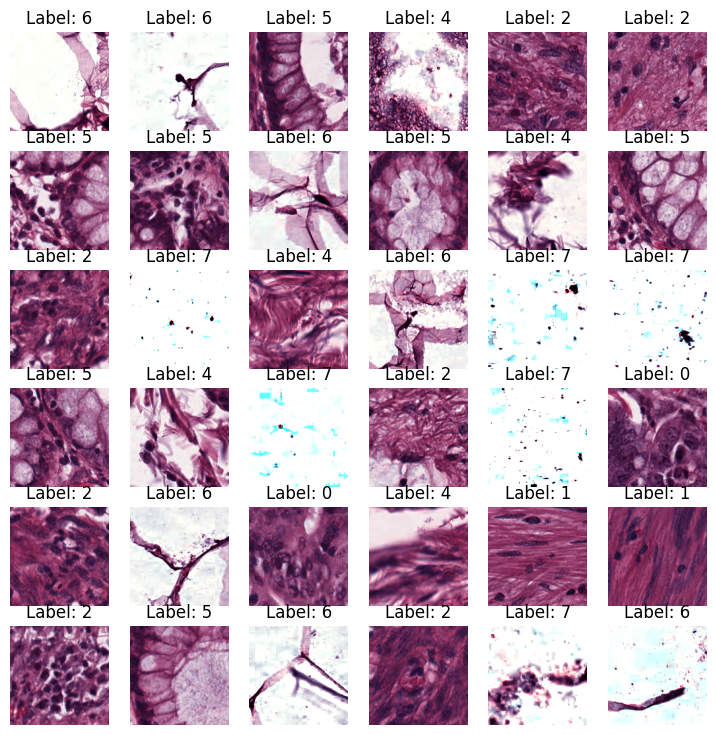

In [15]:
# test transform on other images
fig, axes = plt.subplots(6, 6, figsize=(9, 9))
for i in range(36):
    ax = axes[i // 6, i % 6]
    if i >= len(others_imgs):
        ax.axis('off')
        continue
    img = others_imgs[i]
    label = others_labels[i]
    img, _, _ = normalizer.normalize(img, stains=True)  # input uint8 [3xHxW] 
    # assert the values 0 to 255
    assert img.min() >= 0 and img.max() <= 255, "Output must be in range [0, 255]"
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()

In [76]:
from tqdm import tqdm
# Iterate over the whole dataset and normalize all images
def stained_dataset(dataset, normalizer):
    all_imgs = [] 
    all_labels = []
    for i in tqdm(range(len(dataset))):
        item = dataset[i]
        img, label = item['image'].to(torch.uint8), item['label']
        assert img.min() >= 0 and img.max() <= 255, "Output must be in range [0, 255]"
        try: 
            norm_img, _, _ = normalizer.normalize(img, stains=True)  # input uint8 [3xHxW] 
            # from HWC to CHW
            norm_img = norm_img.permute(2, 0, 1)
            # assert the values 0 to 255
            assert norm_img.min() >= 0 and norm_img.max() <= 255, "Output must be in range [0, 255]"
            all_imgs.append(norm_img)
            all_labels.append(label)
        except Exception as e:
            hsv_img = np.array(Image.fromarray(img.permute(1, 2, 0).numpy(), mode='RGB').convert('HSV'))
            s = hsv_img[..., 1].astype(np.float32) / 255.0
            sat_thresh = 0.15
            tr = float((s > sat_thresh).mean())
            if tr < 0.1:
                # append non-converted
                all_imgs.append(img)
                all_labels.append(label)
                print(f"Image {i} with label {label} is mostly white tr={tr}, added without normalization.")
            else:
                raise e

    all_imgs = torch.stack(all_imgs, dim=0).to(torch.uint8).to('cpu').numpy()
    all_labels = torch.tensor(all_labels, dtype=torch.uint8).to('cpu').numpy()
    return all_imgs, all_labels


In [77]:
train_imgs, train_labels = stained_dataset(train_loader.dataset, normalizer)
valid_imgs, valid_labels = stained_dataset(dataset.val_dataloader().dataset, normalizer)
test_imgs, test_labels = stained_dataset(dataset.test_dataloader().dataset, normalizer)

  1%|          | 44/4000 [00:00<00:17, 225.72it/s]/var/folders/t5/dz3yxr8n7mgd7f9h8bsnqf_w001dhb/T/ipykernel_70693/4076180251.py:19: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hsv_img = np.array(Image.fromarray(img.permute(1, 2, 0).numpy(), mode='RGB').convert('HSV'))
  2%|▏         | 95/4000 [00:00<00:16, 241.35it/s]

Image 60 with label 7 is mostly white tr=0.0, added without normalization.


  6%|▌         | 226/4000 [00:00<00:14, 258.46it/s]

Image 172 with label 7 is mostly white tr=0.0, added without normalization.
Image 184 with label 7 is mostly white tr=0.0, added without normalization.


  7%|▋         | 283/4000 [00:01<00:14, 263.54it/s]

...

 84%|████████▍ | 421/500 [00:02<00:00, 179.55it/s]

Image 387 with label 7 is mostly white tr=0.0, added without normalization.
Image 399 with label 7 is mostly white tr=0.0, added without normalization.


 92%|█████████▏| 460/500 [00:02<00:00, 183.21it/s]

Image 430 with label 7 is mostly white tr=0.0, added without normalization.
Image 462 with label 7 is mostly white tr=0.0, added without normalization.
Image 465 with label 7 is mostly white tr=0.0, added without normalization.


100%|██████████| 500/500 [00:02<00:00, 186.93it/s]


In [80]:
train_imgs.shape, valid_imgs.shape, test_imgs.shape

# save all the datasets as numpy arrays
np.savez_compressed("colorectal_histology_stained.npz",
                    train_imgs=train_imgs,
                    train_labels=train_labels,
                    valid_imgs=valid_imgs,
                    valid_labels=valid_labels,
                    test_imgs=test_imgs,
                    test_labels=test_labels)


In [83]:
# try to load the npz file
data = np.load("colorectal_histology_stained.npz")
data['train_imgs'].shape

(4000, 3, 150, 150)